### Load Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from scipy.stats import normaltest

# Set display options to show all columns and rows (but with scrollbars)
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

In [5]:
ebird = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/ebd_US-WI-025_201801_202401_smp_relFeb-2025/ebd_US-WI-025_201801_202401_smp_relFeb-2025.txt', sep='\t')

/var/folders/3w/875q3kbn2blb9zwp1zjfrhfc0000gn/T/ipykernel_39606/2562786793.py:1: DtypeWarning: Columns (7,8,9,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  ebird = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/ebd_US-WI-025_201801_202401_smp_relFeb-2025/ebd_US-WI-025_201801_202401_smp_relFeb-2025.txt', sep='\t')


In [6]:
prism_WI_dane_county = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/PRISM_tmin_tmean_tmax_stable_4km_20180101_20240101_43.0674_-89.4183.csv', skiprows=10)

### Describe ebird Data

In [ ]:
# 3077056 rows, 49 columns
# OBSERVATION DATE: Date between 2018-01-01 and 2023-12-31
# CATEGORY: no missing value, ~98% identified category is species
# COMMON NAME: bird name, no missing value
# OBSERVATION COUNT: top 3 count birds Canada Goose, American Coot, Mallard
# GEO: all US, WI, Dane County
# Top 5 birding site in Dane county are: Nine Springs Natural Area, UW Madison Arboretum (general), UW Lakeshore Nature Preserve (general), Cherokee Marsh Conservation Park--North Unit, Owen Conservation Park, making up 18% of all site visits
# LATITUDE, LONGITUDE
# 52% checklist submitted are traveling, 31% are stationary
# 27.5% of checklists starts between 5:00 AM - 8:00 AM
# 50% of checklists have duration <= 1 hour
# 50% of checklists have travel distance <= 2.1 km
# Protocol type affects duration distribution. For example, "Stationary" checklists have a median duration of 24 minutes, while "Traveling" checklists have a median duration of 73 minutes.


In [8]:
# initial cleaning
# drop irrelevant column - Unnamed: 49 
ebird = ebird.drop(columns=['Unnamed: 49'])
# keep data between 2018 and 2024
ebird = ebird[(ebird['OBSERVATION DATE'] >= '2018-01-01') & (ebird['OBSERVATION DATE'] <= '2023-12-31')]
# drop presence only no count records
ebird = ebird[ebird['OBSERVATION COUNT'] != 'X']

In [9]:
ebird.head()

,GLOBAL UNIQUE IDENTIFIER,LAST EDITED DATE,TAXONOMIC ORDER,CATEGORY,TAXON CONCEPT ID,COMMON NAME,SCIENTIFIC NAME,SUBSPECIES COMMON NAME,SUBSPECIES SCIENTIFIC NAME,EXOTIC CODE,OBSERVATION COUNT,BREEDING CODE,BREEDING CATEGORY,BEHAVIOR CODE,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,IBA CODE,BCR CODE,USFWS CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,OBSERVER ID,SAMPLING EVENT IDENTIFIER,PROTOCOL TYPE,PROTOCOL CODE,PROJECT CODE,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,NUMBER OBSERVERS,ALL SPECIES REPORTED,GROUP IDENTIFIER,HAS MEDIA,APPROVED,REVIEWED,REASON,TRIP COMMENTS,SPECIES COMMENTS
0,URN:CornellLabOfOrnithology:EBIRD:OBS563870537,2018-08-05 14:55:40,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Jaeger Road - Yahara River,L829178,P,43.005651,-89.302797,2018-01-04,10:27:00,obsr18439,S41613986,Traveling,P22,EBIRD,10.0,0.322,NaN,1.0,1,NaN,0,1,0,NaN,NaN,NaN
1,URN:CornellLabOfOrnithology:EBIRD:OBS566677532,2018-08-05 14:55:52,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Jaeger Lane,L6707992,P,43.006504,-89.301510,2018-01-12,09:30:00,obsr602297,S41848418,Stationary,P21,EBIRD,15.0,NaN,NaN,1.0,1,NaN,0,1,0,NaN,NaN,NaN
2,URN:CornellLabOfOrnithology:EBIRD:OBS562751969,2024-04-26 21:57:24.237189,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,UW Madison Arboretum--Spring Trail Pond,L2565737,H,43.050024,-89.436577,2018-01-01,10:50:00,obsr212877,S41517897,Traveling,P22,EBIRD,90.0,0.805,NaN,4.0,1,G2826047,0,1,0,NaN,NaN,NaN
3,URN:CornellLabOfOrnithology:EBIRD:OBS565294693,2021-04-01 21:33:26.357322,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Babcock County Park,L662891,H,43.008319,-89.306188,2018-01-06,13:50:00,obsr308383,S41681743,Stationary,P21,EBIRD,23.0,NaN,NaN,2.0,1,G2844496,0,1,0,NaN,NaN,NaN
4,URN:CornellLabOfOrnithology:EBIRD:OBS572121515,2021-03-30 02:26:51.250642,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Mud Lake,L2035558,P,42.993599,-89.290008,2018-01-28,NaN,obsr88771,S42316514,Historical,P62,EBIRD,NaN,NaN,NaN,NaN,1,NaN,0,1,0,NaN,NaN,NaN


In [10]:
ebird.shape

(2941268, 49)

In [11]:
ebird['OBSERVATION DATE'].agg(['min', 'max'])

min    2018-01-01
max    2023-12-31
Name: OBSERVATION DATE, dtype: object

In [12]:
# columns with missing value
missing_pct = ebird.isnull().mean() * 100
missing_pct[missing_pct > 0]

SUBSPECIES COMMON NAME         98.808065
SUBSPECIES SCIENTIFIC NAME     98.808065
EXOTIC CODE                    93.673681
BREEDING CODE                  97.436548
BREEDING CATEGORY              97.436548
BEHAVIOR CODE                  97.436548
AGE/SEX                        99.360310
IBA CODE                       86.391413
USFWS CODE                     97.869932
ATLAS BLOCK                    97.117400
TIME OBSERVATIONS STARTED       0.243092
DURATION MINUTES                3.395338
EFFORT DISTANCE KM             24.344942
EFFORT AREA HA                 99.894467
NUMBER OBSERVERS                0.220925
GROUP IDENTIFIER               77.156451
REASON                        100.000000
TRIP COMMENTS                  86.392807
SPECIES COMMENTS               96.402844
dtype: float64

In [13]:
# ebird['CATEGORY'].isnull().mean() * 100
ebird['CATEGORY'].value_counts(normalize=True) * 100

CATEGORY
species     97.789355
spuh         0.823148
issf         0.667739
domestic     0.440320
slash        0.173225
form         0.095877
hybrid       0.010336
Name: proportion, dtype: float64

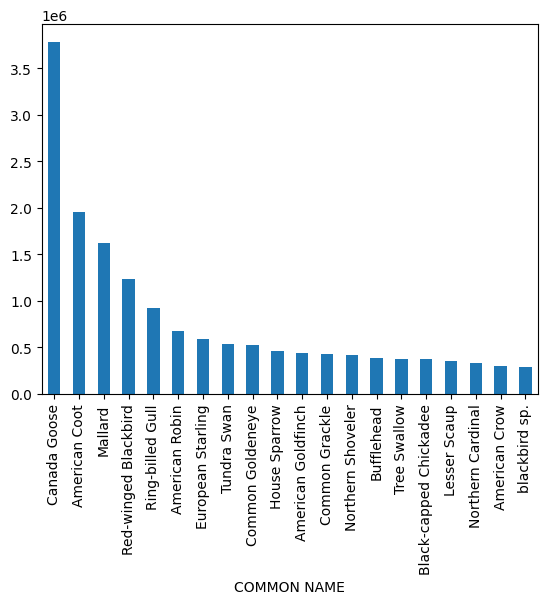

In [14]:
# convert OBSERVATION COUNT to numeric
ebird['OBSERVATION COUNT'] = pd.to_numeric(ebird['OBSERVATION COUNT'])
(ebird.groupby('COMMON NAME')['OBSERVATION COUNT'].sum().nlargest(20).plot(kind='bar'))
plt.show()

In [15]:
# Top 3 species diversity site: Nine Springs Natural Area - 299, UW Lakeshore Nature Preserve (general) - 295, Cherokee Marsh Conservation Park--North Unit - 282, and represent 78% of specieces diversity in Dane county
ebird.groupby('LOCALITY')['COMMON NAME'].nunique().nlargest(5)

LOCALITY
Nine Springs Natural Area                       299
UW Lakeshore Nature Preserve (general)          295
Cherokee Marsh Conservation Park--North Unit    282
UW Madison Arboretum (general)                  274
Lake Farm County Park                           269
Name: COMMON NAME, dtype: int64

In [16]:
# Filter for specific locations
locations = [
    'Nine Springs Natural Area', 
    'UW Lakeshore Nature Preserve (general)', 
    'Cherokee Marsh Conservation Park--North Unit'
]
filtered = ebird[ebird['LOCALITY'].isin(locations)]

# Count unique species per location
counts = filtered['COMMON NAME'].nunique()

# Calculate percentage of total unique species
total_unique = ebird['COMMON NAME'].nunique()
percentages = round((counts / total_unique * 100),2)

print(percentages)

78.48


In [17]:
# Top 3 bird abundance in Dane county are: Nine Springs Natural Area, Lake Farm County Park, Cherokee Marsh Conservation Park--North Unit, making up 14% of overall observed population
ebird.groupby('LOCALITY')['OBSERVATION COUNT'].sum().nlargest(5)

LOCALITY
Nine Springs Natural Area                       1831727
Lake Farm County Park                            871581
Cherokee Marsh Conservation Park--North Unit     797145
UW Madison Arboretum (general)                   736645
UW Lakeshore Nature Preserve (general)           726498
Name: OBSERVATION COUNT, dtype: int64

In [16]:
# Filter for specific locations
locations = [
    'Nine Springs Natural Area', 
    'Lake Farm County Park', 
    'Cherokee Marsh Conservation Park--North Unit'
]
filtered = ebird[ebird['LOCALITY'].isin(locations)]

# Count unique species per location
counts = filtered['OBSERVATION COUNT'].sum()

# Calculate percentage of total unique species
total_count = ebird['OBSERVATION COUNT'].sum()
percentages = round((counts / total_count * 100),2)

print(percentages)

14.29


In [ ]:
# Top 3 most visited spots - UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park, represents of 7% total visits
ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().nlargest(3)

LOCALITY
UW Madison Arboretum (general)    6165
Nine Springs Natural Area         5467
Owen Conservation Park            3745
Name: SAMPLING EVENT IDENTIFIER, dtype: int64

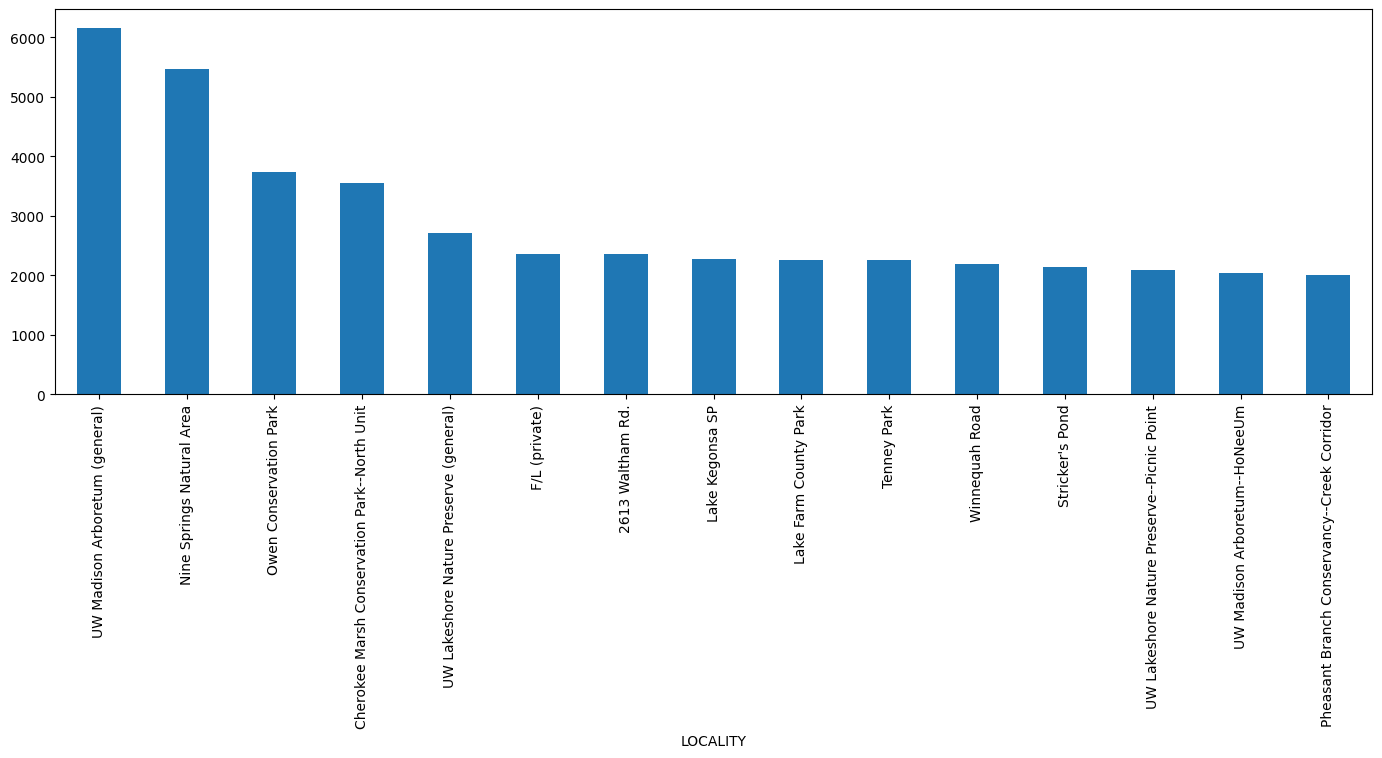

In [39]:
(ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().nlargest(15).plot(kind='bar', figsize=(17, 5)))
plt.show()

In [28]:
# Filter for specific locations
locations = [
    'Nine Springs Natural Area', 
    'UW Madison Arboretum (general)', 
    'Owen Conservation Park'
]
filtered = ebird[ebird['LOCALITY'].isin(locations)]

# Count unique species per location
counts = filtered['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage of total unique species
total_count = ebird['SAMPLING EVENT IDENTIFIER'].nunique()
percentages = round((counts / total_count * 100),2)

print(percentages)

7.18


In [42]:
(ebird.groupby('PROTOCOL TYPE')['SAMPLING EVENT IDENTIFIER']
     .nunique()
     .div(ebird['SAMPLING EVENT IDENTIFIER'].nunique())
     .mul(100)
     .round(1)
     .sort_values(ascending=False))

PROTOCOL TYPE
Traveling                        52.6
Stationary                       31.0
Incidental                       15.7
Historical                        0.6
Area                              0.1
Traveling - Property Specific     0.1
Banding                           0.0
Nocturnal Flight Call Count       0.0
PROALAS                           0.0
eBird Pelagic Protocol            0.0
Name: SAMPLING EVENT IDENTIFIER, dtype: float64

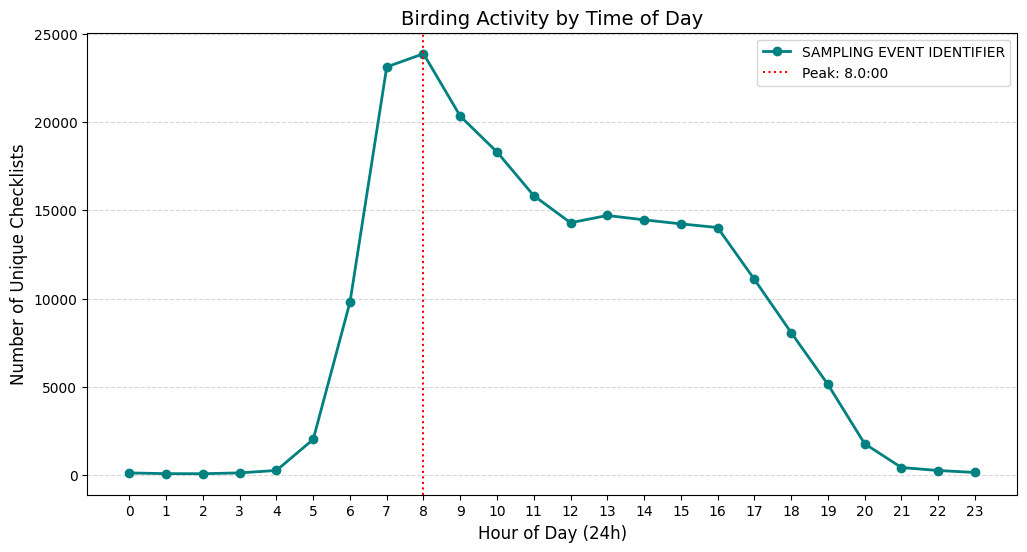

In [80]:
# Convert time to datetime and extract hour
ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED'], format='%H:%M:%S').dt.hour

# Count unique checklists per hour
hourly_counts = ebird.groupby('HOUR')['SAMPLING EVENT IDENTIFIER'].nunique()

# Plot line graph
plt.figure(figsize=(12, 6))
hourly_counts.plot(
    kind='line',
    marker='o',      # Add dots for each data point
    linestyle='-',    # Solid line
    linewidth=2,
    color='teal'
)

# Customize plot
plt.title('Birding Activity by Time of Day', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Unique Checklists', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight peak hours
peak_hour = hourly_counts.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle=':', label=f'Peak: {peak_hour}:00')
plt.legend()

plt.show()

In [ ]:
# Calculate total unique checklists
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()

# Count checklists between 5-8 AM
morning_checklists = ebird[ebird['HOUR'].between(5, 8)]['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage
morning_percentage = (morning_checklists / total_checklists) * 100

print(f"{morning_percentage:.1f}% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.")

27.5% of checklists starts between 5:00 AM - 8:00 AM


In [ ]:
# Show entries with suspiciously long durations (e.g., > 24 hours)
# There are a few entries with extremely long durations, which may be errors
ebird[ebird['DURATION MINUTES'] > 1440][['DURATION MINUTES', 'PROTOCOL TYPE']]

,DURATION MINUTES,PROTOCOL TYPE
707353,2945.0,Traveling
716547,2945.0,Traveling
739972,2945.0,Traveling
745528,2945.0,Traveling
771941,1939.0,Traveling
809839,1939.0,Traveling
821294,1939.0,Traveling
852107,1939.0,Traveling
897303,1939.0,Traveling
1184151,2919.0,Traveling


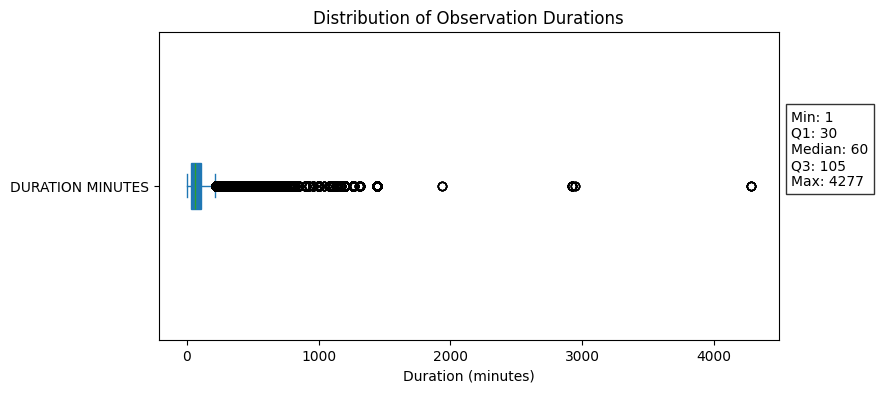

In [ ]:
# Generate boxplot for duration
# 50% of checklists have duration <= 1 hour

plt.figure(figsize=(8, 4))

ebird['DURATION MINUTES'].plot(kind='box', vert=False, patch_artist=True)
plt.title('Distribution of Observation Durations')
plt.xlabel('Duration (minutes)')

# Annotate stats
stats = ebird['DURATION MINUTES'].describe()
text = f"""Min: {stats['min']:.0f}
Q1: {stats['25%']:.0f}
Median: {stats['50%']:.0f}
Q3: {stats['75%']:.0f}
Max: {stats['max']:.0f}"""
plt.text(1.02, 0.5, text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

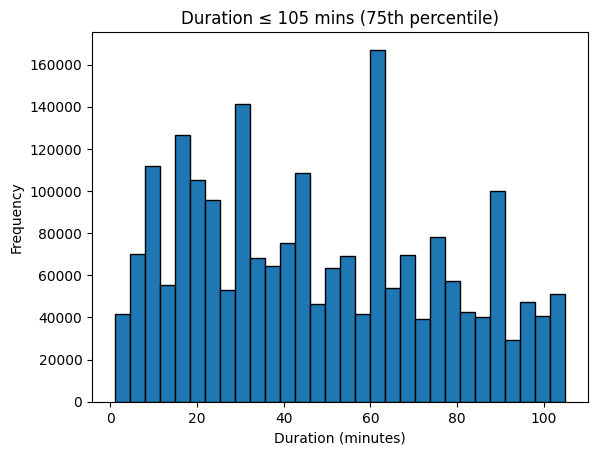

In [ ]:
# Get duration distribution for 75% quantile

# Calculate 75th percentile
p75 = ebird['DURATION MINUTES'].quantile(0.75)

# Filter and plot
subset = ebird[ebird['DURATION MINUTES'] <= p75]
subset['DURATION MINUTES'].plot(kind='hist', bins=30, edgecolor='black')
plt.title(f'Duration ≤ {p75:.0f} mins (75th percentile)')
plt.xlabel('Duration (minutes)')
plt.show()

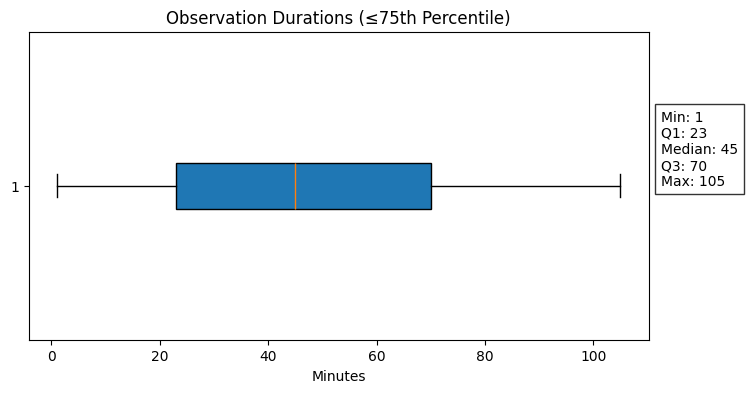

In [ ]:
# Generate boxplot for under 75% quantile duration
plt.figure(figsize=(8, 4))
box = plt.boxplot(subset['DURATION MINUTES'], vert=False, patch_artist=True)
plt.title('Observation Durations (≤75th Percentile)')
plt.xlabel('Minutes')

# Annotate stats
stats = subset['DURATION MINUTES'].describe()
text = f"""Min: {stats['min']:.0f}
Q1: {stats['25%']:.0f}
Median: {stats['50%']:.0f}
Q3: {stats['75%']:.0f}
Max: {stats['max']:.0f}"""
plt.text(1.02, 0.5, text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [ ]:
# Protocol type affects duration distribution. For example, "Stationary" checklists have a median duration of 24 minutes, while "Traveling" checklists have a median duration of 73 minutes.
ebird.groupby('PROTOCOL TYPE')['DURATION MINUTES'].describe()

,count,mean,std,min,25%,50%,75%,max
PROTOCOL TYPE,,,,,,,,
Area,2533.0,67.297276,35.415181,5.0,50.0,60.0,75.0,240.0
Banding,470.0,288.063830,62.821677,45.0,240.0,285.0,330.0,420.0
Historical,3384.0,80.745567,66.106566,1.0,30.0,63.0,120.0,380.0
Incidental,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nocturnal Flight Call Count,123.0,285.439024,206.967375,1.0,53.0,300.0,435.0,651.0
PROALAS,5.0,30.000000,0.000000,30.0,30.0,30.0,30.0,30.0
Stationary,610837.0,39.959837,61.897556,1.0,12.0,24.0,45.0,1440.0
Traveling,2219473.0,85.156707,64.547384,1.0,41.0,73.0,115.0,4277.0
Traveling - Property Specific,4493.0,97.245716,67.410246,5.0,50.0,80.0,131.0,390.0


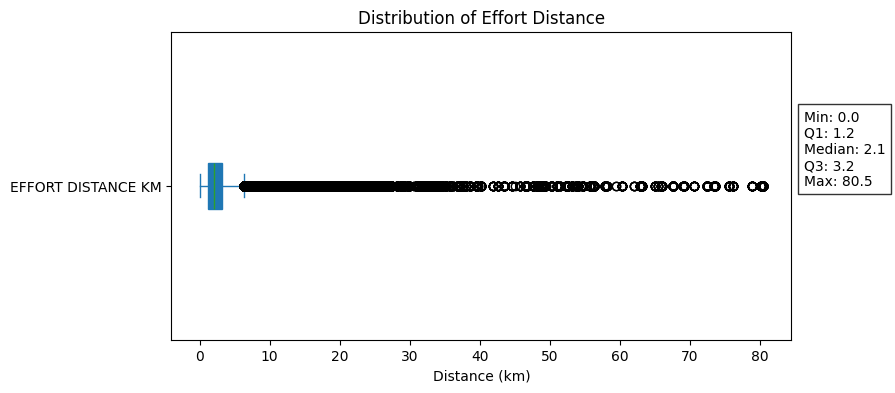

In [102]:
# boxplot for EFFORT DISTANCE KM

plt.figure(figsize=(8, 4))

ebird['EFFORT DISTANCE KM'].plot(kind='box', vert=False, patch_artist=True)
plt.title('Distribution of Effort Distance')
plt.xlabel('Distance (km)')

# Annotate stats
stats = ebird['EFFORT DISTANCE KM'].describe()
text = f"""Min: {stats['min']:.1f}
Q1: {stats['25%']:.1f}
Median: {stats['50%']:.1f}
Q3: {stats['75%']:.1f}
Max: {stats['max']:.1f}"""
plt.text(1.02, 0.5, text, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

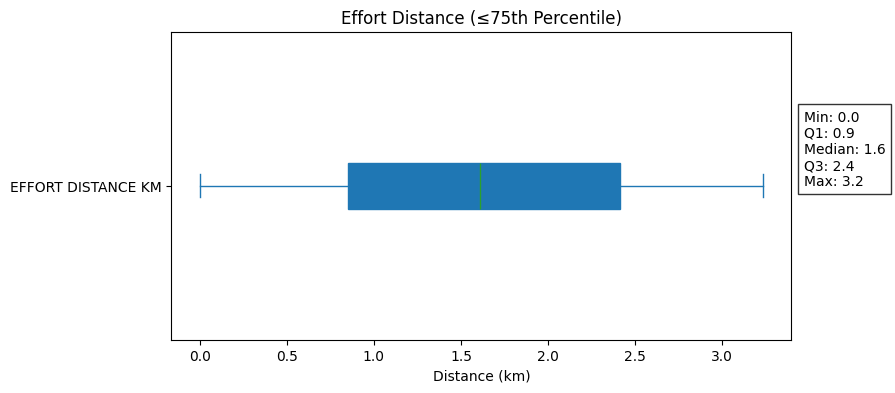

In [103]:
# boxplot for EFFORT DISTANCE KM, 75% quantile

# Calculate 75th percentile and filter
p75 = ebird['EFFORT DISTANCE KM'].quantile(0.75)
subset = ebird[ebird['EFFORT DISTANCE KM'] <= p75]

# Generate plot
plt.figure(figsize=(8, 4))
subset['EFFORT DISTANCE KM'].plot(kind='box', vert=False, patch_artist=True)
plt.title('Effort Distance (≤75th Percentile)')
plt.xlabel('Distance (km)')

# Annotate stats
stats = subset['EFFORT DISTANCE KM'].describe()
text = f"""Min: {stats['min']:.1f}
Q1: {stats['25%']:.1f}
Median: {stats['50%']:.1f}
Q3: {stats['75%']:.1f}
Max: {stats['max']:.1f}"""
plt.text(1.02, 0.5, text, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

### Exploratory Analysis

In [119]:
# Extract temporal features
ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour
ebird['DAY_OF_WEEK'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.day_name()
ebird['MONTH'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.month_name()

/var/folders/3w/875q3kbn2blb9zwp1zjfrhfc0000gn/T/ipykernel_39606/3493306810.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour


#### Trend Analysis

##### Does birder in Dane County's favorite site changes every year between 2018-2023?

** favoriate site defined as highest checklist submitted

In [118]:
(
    ebird.groupby(['YEAR', 'LOCALITY'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .groupby('YEAR', group_keys=False)
    .nlargest(3)
    .reset_index(name='CHECKLIST COUNT')
)

,YEAR,LOCALITY,CHECKLIST COUNT
0,2018,UW Madison Arboretum (general),850
1,2018,F/L (private),453
2,2018,2613 Waltham Rd.,431
3,2019,UW Madison Arboretum (general),844
4,2019,2613 Waltham Rd.,566
5,2019,F/L (private),408
6,2020,UW Madison Arboretum (general),1017
7,2020,Owen Conservation Park,833
8,2020,Cherokee Marsh Conservation Park--North Unit,779
9,2021,UW Madison Arboretum (general),1216


##### Has there been an increasing number of checklists submitted by birders in Dane?

<Axes: xlabel='OBSERVATION DATE'>

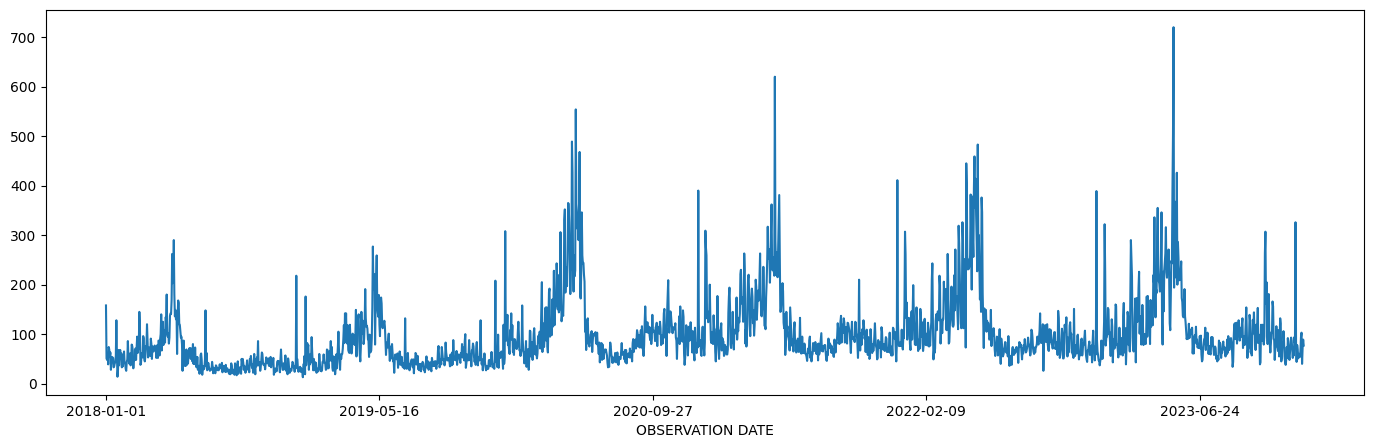

In [65]:
# unique checklist submitted by date
ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique().sort_index().plot(figsize=(17, 5))

In [54]:
ts = ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique()
stat, p = normaltest(ts)  # D'Agostino-Pearson test
print(f"Normality p-value: {p:.4f}")  # p < 0.05 → Not Gaussian

Normality p-value: 0.0000


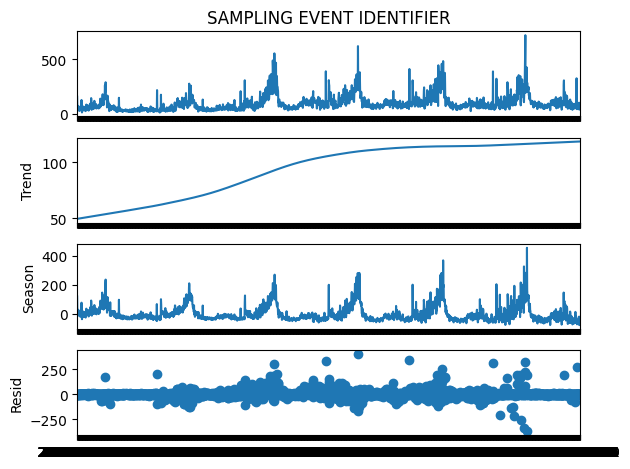

Trend slope: 0.035 (checklists/day), p-value: 0.0000


In [73]:
# there is a stats sig increase in the number of checklists submitted over time between 2018 and 2023

from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Prepare daily counts
ts = ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique()

# Decompose trend + seasonality
stl = STL(ts, period=365, robust=True).fit()  # 365 for yearly seasonality
stl.plot()
plt.show()

# Trend slope (simple linear regression on trend component)
from scipy.stats import linregress
trend_slope, _, _, pvalue, _ = linregress(
    x=np.arange(len(stl.trend)),
    y=stl.trend.dropna()
)
print(f"Trend slope: {trend_slope:.3f} (checklists/day), p-value: {pvalue:.4f}")

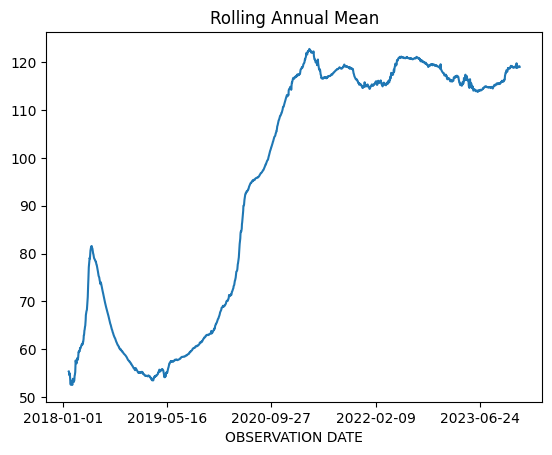

In [74]:
# Plot 365-day rolling mean to visualize trend
ts.rolling(365, min_periods=30).mean().plot(title="Rolling Annual Mean")
plt.show()

In [ ]:
# Compare current year to previous year (YoY change)
ts.index = pd.to_datetime(ts.index)  # Ensure index is datetime
yearly_growth = ts.groupby(ts.index.year).sum().pct_change().dropna()
print(f"Yearly growth rates:\n{yearly_growth}")

Yearly growth rates:
OBSERVATION DATE
2019    0.170101
2020    0.786492
2021    0.002333
2022    0.019975
2023    0.011690
Name: SAMPLING EVENT IDENTIFIER, dtype: float64


##### Has there been an increasing number of oberseved specieces submitted through ebird in Dane?

<Axes: xlabel='OBSERVATION DATE'>

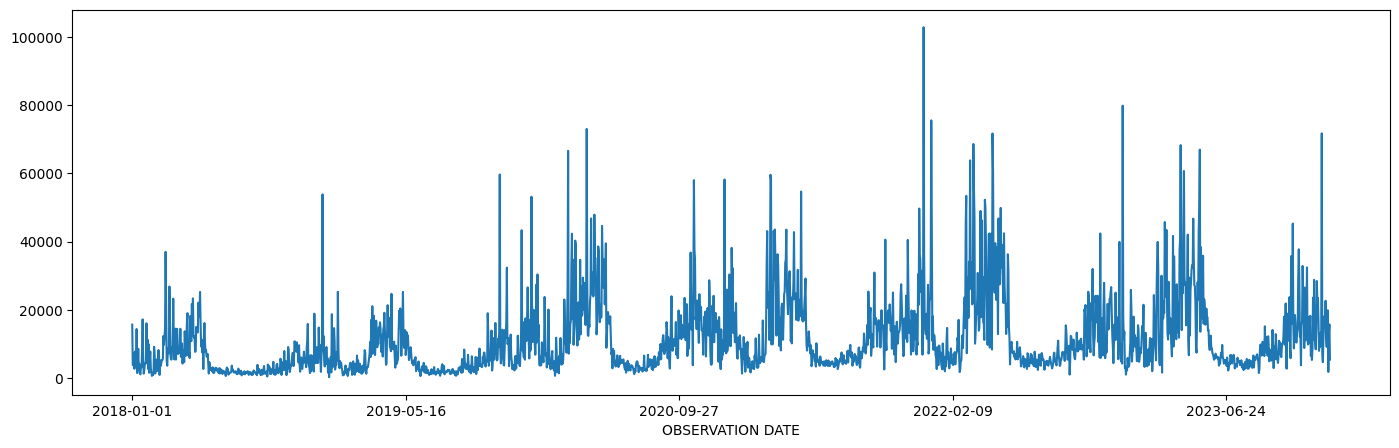

In [ ]:
ebird.groupby('OBSERVATION DATE')['OBSERVATION COUNT'].sum().sort_index().plot(figsize=(17, 5))

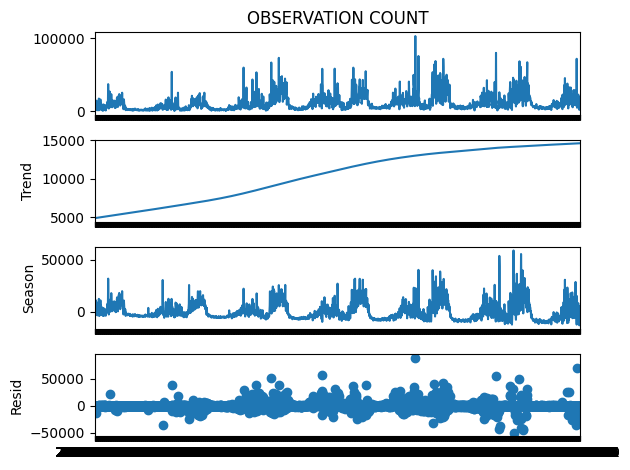

Trend slope: 5.000 (observed count/day), p-value: 0.0000


In [76]:
# yes - there is a stats sig increase in observed bird count over time between 2018 and 2023

# Prepare daily counts
ts = ebird.groupby('OBSERVATION DATE')['OBSERVATION COUNT'].sum()

# Decompose trend + seasonality
stl = STL(ts, period=365, robust=True).fit()  # 365 for yearly seasonality
stl.plot()
plt.show()

# Trend slope (simple linear regression on trend component)
from scipy.stats import linregress
trend_slope, _, _, pvalue, _ = linregress(
    x=np.arange(len(stl.trend)),
    y=stl.trend.dropna()
)
print(f"Trend slope: {trend_slope:.3f} (observed count/day), p-value: {pvalue:.4f}")

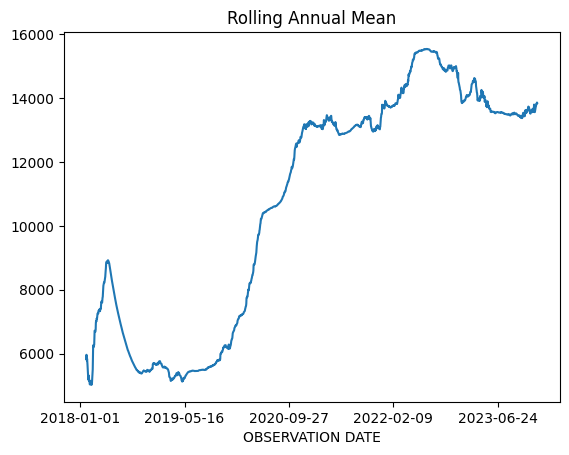

In [77]:
# Plot 365-day rolling mean to visualize trend
ts.rolling(365, min_periods=30).mean().plot(title="Rolling Annual Mean")
plt.show()

In [78]:
# Compare current year to previous year (YoY change)
ts.index = pd.to_datetime(ts.index)  # Ensure index is datetime
yearly_growth = ts.groupby(ts.index.year).sum().pct_change().dropna()
print(f"Yearly growth rates:\n{yearly_growth}")

Yearly growth rates:
OBSERVATION DATE
2019    0.149367
2020    1.044420
2021    0.037510
2022    0.023203
2023   -0.017213
Name: OBSERVATION COUNT, dtype: float64


##### Has there been shifts in birding habits across years?

* Time of day: consistent pattern, but observed spike in checklist submitted in 2020, checklist submitted almost doubled staring from 2020 when comparing to 2019.
* Day of Week: consistent

<Figure size 1200x600 with 0 Axes>

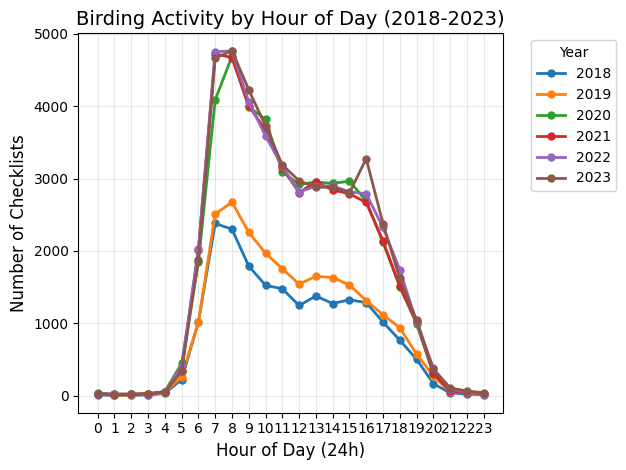

In [124]:
plt.figure(figsize=(12, 6))

# Group by year and hour, then count checklists
hourly_by_year = (
    ebird.groupby(['YEAR', 'HOUR'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Plot each year's line
hourly_by_year.plot(kind='line', marker='o', linewidth=2, markersize=5)

# Customize plot
plt.title('Birding Activity by Hour of Day (2018-2023)', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Checklists', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

# Move legend outside
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [126]:
# Count unique checklists per year
yearly_counts = ebird.groupby('YEAR')['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage of total
yearly_pct = (yearly_counts / yearly_counts.sum() * 100).round(1)

# Combine into a clean DataFrame
result = pd.DataFrame({
    'Checklist Count': yearly_counts,
    'Percentage (%)': yearly_pct
})

print(result)

      Checklist Count  Percentage (%)
YEAR                                 
2018            20094             9.4
2019            23512            11.0
2020            42004            19.6
2021            42102            19.7
2022            42943            20.1
2023            43445            20.3


<Figure size 1200x500 with 0 Axes>

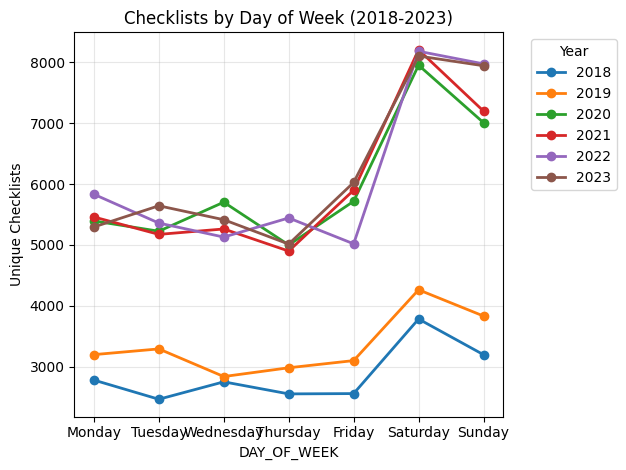

In [127]:
# Count checklists by year and day of week
dow_counts = (
    ebird.groupby(['YEAR', 'DAY_OF_WEEK'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Reorder days (Monday to Sunday)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.loc[dow_order]

# Plot
plt.figure(figsize=(12, 5))
dow_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Checklists by Day of Week (2018-2023)')
plt.ylabel('Unique Checklists')
plt.grid(alpha=0.3)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

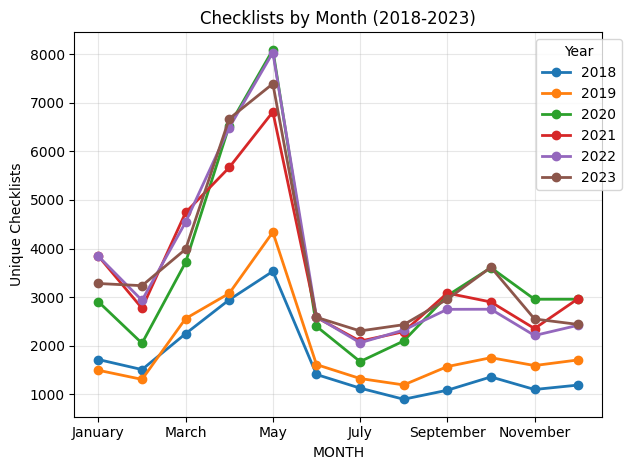

In [128]:
# Count checklists by year and month
month_counts = (
    ebird.groupby(['YEAR', 'MONTH'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = month_counts.loc[month_order]

# Plot
plt.figure(figsize=(12, 5))
month_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Checklists by Month (2018-2023)')
plt.ylabel('Unique Checklists')
plt.grid(alpha=0.3)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

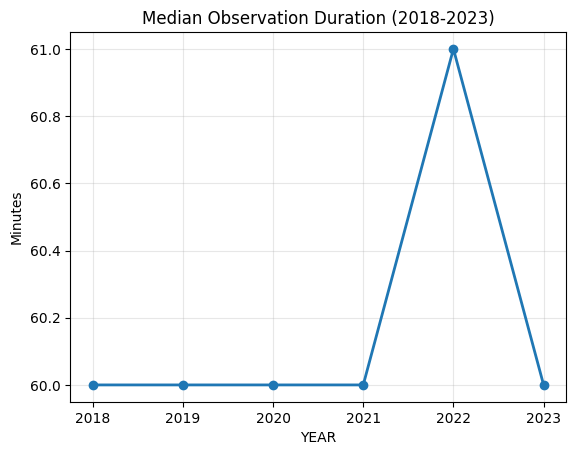

In [129]:
duration = (
    ebird.groupby('YEAR')['DURATION MINUTES']
    .median()
    .to_frame('Median Duration (min)')
)

plt.figure(figsize=(8, 4))
duration.plot(kind='line', marker='o', linewidth=2, legend=False)
plt.title('Median Observation Duration (2018-2023)')
plt.ylabel('Minutes')
plt.grid(alpha=0.3)
plt.xticks(duration.index)
plt.show()

<Figure size 800x400 with 0 Axes>

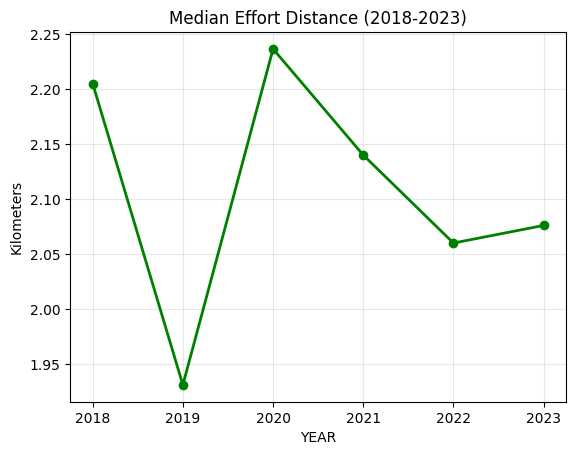

In [130]:
distance = (
    ebird.groupby('YEAR')['EFFORT DISTANCE KM']
    .median()
    .to_frame('Median Distance (km)')
)

plt.figure(figsize=(8, 4))
distance.plot(kind='line', marker='o', linewidth=2, color='green', legend=False)
plt.title('Median Effort Distance (2018-2023)')
plt.ylabel('Kilometers')
plt.grid(alpha=0.3)
plt.xticks(distance.index)
plt.show()

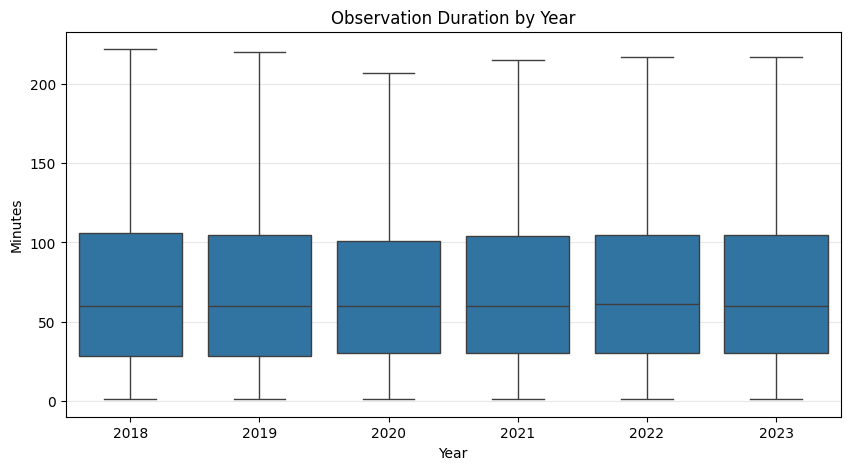

In [132]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=ebird,
    x='YEAR',
    y='DURATION MINUTES',
    showfliers=False  # Exclude outliers for cleaner plot
)
plt.title('Observation Duration by Year')
plt.xlabel('Year')
plt.ylabel('Minutes')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Describe PRISM Data

In [16]:
prism_WI_dane_county.tail()

,Date,tmin (degrees F),tmean (degrees F),tmax (degrees F)
2187,2023-12-28,30.0,35.7,41.4
2188,2023-12-29,31.7,33.0,34.3
2189,2023-12-30,21.2,29.6,38.0
2190,2023-12-31,24.9,31.4,37.8
2191,2024-01-01,26.1,28.5,30.9


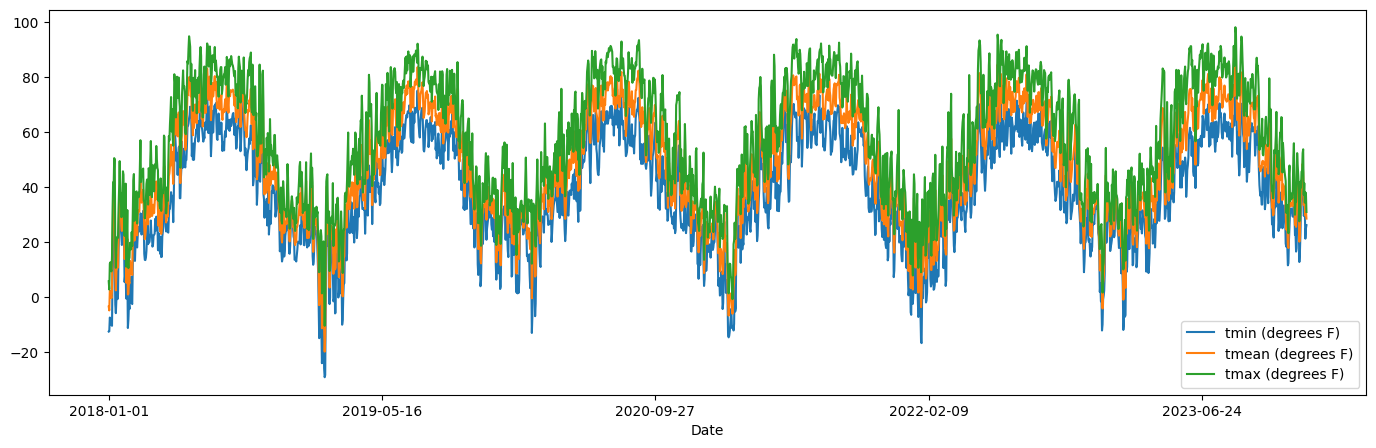

In [15]:
prism_WI_dane_county.plot(x='Date', y=['tmin (degrees F)', 'tmean (degrees F)', 'tmax (degrees F)'], kind='line', figsize=(17, 5))
plt.show()

### Limit to only required columns

In [ ]:
cols = ['OBSERVATION DATE', 'COMMON NAME', 'OBSERVATION COUNT', 'COUNTRY', 'STATE', 'COUNTY', 'LOCALITY', 'LATITUDE', 'LONGITUDE']
ebird = ebird[cols]

In [ ]:
ebird['OBSERVATION DATE'] = pd.to_datetime(ebird['OBSERVATION DATE'])
ebird['YEAR'] = ebird['OBSERVATION DATE'].dt.year
ebird['MONTH'] = ebird['OBSERVATION DATE'].dt.month

In [ ]:
ebird